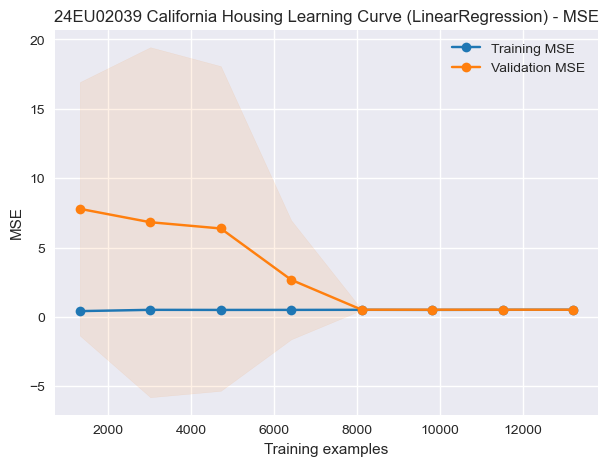

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use("seaborn-v0_8")
%matplotlib inline

data = fetch_california_housing(as_frame=True)
df_all = data.frame
X = df_all.drop(columns=["MedHouseVal"])
y = df_all["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "SVR_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=10.0, epsilon=0.1))
    ])
}

def plot_learning_curve_for_model(model, model_name, X, y, scoring="neg_mean_squared_error"):
    train_sizes, train_scores, valid_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring=scoring,
        n_jobs=-1
    )
    train_mse = -train_scores
    valid_mse = -valid_scores
    train_mean = np.mean(train_mse, axis=1)
    train_std = np.std(train_mse, axis=1)
    valid_mean = np.mean(valid_mse, axis=1)
    valid_std = np.std(valid_mse, axis=1)
    plt.figure(figsize=(7, 5))
    plt.title(f"24EU02039 California Housing Learning Curve ({model_name}) - MSE")
    plt.xlabel("Training examples")
    plt.ylabel("MSE")
    plt.plot(train_sizes, train_mean, "o-", color="tab:blue", label="Training MSE")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="tab:blue")
    plt.plot(train_sizes, valid_mean, "o-", color="tab:orange", label="Validation MSE")
    plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="tab:orange")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

def evaluate_regression_model(model, model_name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    print(f"=== 24EU02039 California Housing {model_name} ===")
    print(f"Train MSE : {train_mse:.4f}")
    print(f"Test  MSE : {test_mse:.4f}")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test  RMSE: {test_rmse:.4f}")
    print(f"Train MAE : {train_mae:.4f}")
    print(f"Test  MAE : {test_mae:.4f}")
    print(f"Train R^2 : {train_r2:.4f}")
    print(f"Test  R^2 : {test_r2:.4f}")
    print()

def cross_validated_metrics(model, model_name, X, y):
    neg_mse_scores = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
    mse_scores = -neg_mse_scores
    rmse_scores = np.sqrt(mse_scores)
    r2_scores = cross_val_score(model, X, y, cv=5, scoring="r2", n_jobs=-1)
    print(f"=== 24EU02039 Cross-validated {model_name} ===")
    print(f"MSE  mean: {mse_scores.mean():.4f}  std: {mse_scores.std():.4f}")
    print(f"RMSE mean: {rmse_scores.mean():.4f}  std: {rmse_scores.std():.4f}")
    print(f"R^2  mean: {r2_scores.mean():.4f}  std: {r2_scores.std():.4f}")
    print()

for name, model in models.items():
    plot_learning_curve_for_model(model, name, X_train, y_train)

for name, model in models.items():
    evaluate_regression_model(model, name, X_train, y_train, X_test, y_test)

for name, model in models.items():
    cross_validated_metrics(model, name, X, y)